<a href="https://colab.research.google.com/github/mayracastrohe/rappiplus-business-analysis/blob/main/S12_Estudiante_Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [ ]:
# importar librerías
import pandas as pd
import numpy as np

In [ ]:
# cargar archivos
orders = pd.read_csv('rappiplus_orders_raw.csv')
catalog = pd.read_csv('rappiplus_catalog.csv')
marketing = pd.read_csv('rappiplus_marketing_spend.csv')

In [ ]:
# explorar datasets
# tu código aquí

In [ ]:
for nombre, df in [('orders', orders), ('catalog', catalog), ('marketing', marketing)]:
    print(f'--- {nombre} ---')
    print('Shape:', df.shape)
    print(df.info())
    print(df.head())
    print()

--- orders ---
Shape: (25100, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB
None
  id_pedido id_usuario fecha_hora_pedido       pais dispositivo  \
0   order_0  user_6993        2025-05-22  Argen

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
# tu código aquí
# orders

In [ ]:
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')

In [ ]:
orders['pais'] = orders['pais'].str.strip().str.capitalize()
orders['dispositivo'] = orders['dispositivo'].str.strip().str.lower()
orders['fuente_referencia'] = orders['fuente_referencia'].str.strip().str.lower()
orders['nombre_producto'] = orders['nombre_producto'].str.strip()

In [ ]:
orders['categoria_producto'] = orders['categoria_producto'].replace({
    'Electronica': 'Electrónica'})

In [ ]:
orders = orders.drop_duplicates(subset='id_pedido')

In [ ]:
orders['es_devolucion'] = (orders['cantidad'] < 0) | (orders['monto_total'] < 0)
print('Posibles devoluciones detectadas:', orders['es_devolucion'].sum())

Posibles devoluciones detectadas: 4


In [ ]:
q1 = orders['monto_total'].quantile(0.25)
q3 = orders['monto_total'].quantile(0.75)
iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr
orders['outlier_monto'] = orders['monto_total'] > limite_superior
print('Outliers detectados (se mantienen marcados, no se borran):', orders['outlier_monto'].sum())

Outliers detectados (se mantienen marcados, no se borran): 10


In [ ]:
cols_categoricas = ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']
orders[cols_categoricas] = orders[cols_categoricas].fillna('Desconocido')

In [ ]:
cols_numericas = ['cantidad', 'precio_unitario', 'monto_descuento']
for col in cols_numericas:
    orders[col] = orders[col].fillna(orders[col].median())

print(orders.shape)
print(orders.isnull().sum())

(25000, 14)
id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
es_devolucion         0
outlier_monto         0
dtype: int64


In [ ]:
# catalog
catalog['nombre_producto'] = catalog['nombre_producto'].str.strip()
catalog['categoria_producto'] = catalog['categoria_producto'].str.strip()
catalog['proveedor'] = catalog['proveedor'].str.strip()

catalog = catalog.drop_duplicates(subset='nombre_producto')
catalog = catalog[catalog['costo_unitario'] > 0]

print(catalog.shape)
print(catalog.isnull().sum())

(7, 4)
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64


In [ ]:
# marketing
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='coerce')
marketing['pais'] = marketing['pais'].str.strip().str.capitalize()

marketing['canal'] = marketing['canal'].fillna(marketing['id_campaña'].str.extract(r'^([a-z_]+)_')[0])

marketing = marketing.drop_duplicates()
marketing = marketing[marketing['gasto'] > 0]

print(marketing.shape)
print(marketing.isnull().sum())
print(marketing['canal'].unique())

(1620, 5)
fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64
['organic' 'paid_search' 'social']


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
# PARTE 1: Rentabilidad del negocio

# Revenue bruto: solo ventas reales, sin contar devoluciones
revenue_bruto = orders.loc[~orders['es_devolucion'], 'monto_total'].sum()

# Revenue neto: incluye las devoluciones (montos negativos), refleja el ingreso real
revenue_neto = orders['monto_total'].sum()

print(f'Revenue bruto (sin devoluciones): ${revenue_bruto:,.2f}')
print(f'Revenue neto (con devoluciones):  ${revenue_neto:,.2f}')
print(f'Impacto de devoluciones:          ${revenue_bruto - revenue_neto:,.2f}')

Revenue bruto (sin devoluciones): $51,988,609.56
Revenue neto (con devoluciones):  $51,987,462.26
Impacto de devoluciones:          $1,147.30


In [ ]:
# Costo total: cruzar orders con catalog para obtener costo_unitario
orders_costo = orders.merge(catalog[['nombre_producto', 'costo_unitario']],
                              on='nombre_producto', how='left')
orders_costo['costo_total_linea'] = orders_costo['cantidad'] * orders_costo['costo_unitario']
costo_total = orders_costo['costo_total_linea'].sum()
print(f'Costo total: ${costo_total:,.2f}')

Costo total: $43,132,275.89


In [ ]:
# Inversión en marketing
inversion_marketing = marketing['gasto'].sum()
print(f'Inversión en marketing: ${inversion_marketing:,.2f}')

Inversión en marketing: $2,871,843.53


In [ ]:
# Profit (usamos revenue neto, es el ingreso real después de devoluciones)
profit = revenue_neto - costo_total - inversion_marketing
print(f'Profit: ${profit:,.2f}')
print('¿Es rentable?', 'Sí ✅' if profit > 0 else 'No ❌')

Profit: $5,983,342.84
¿Es rentable? Sí ✅


In [ ]:
# PARTE 2: Comportamiento de ventas

n_pedidos = orders['id_pedido'].nunique()

# Ticket promedio por orden
ticket_promedio = revenue_neto / n_pedidos
print(f'Ticket promedio por orden: ${ticket_promedio:,.2f}')

Ticket promedio por orden: $2,079.50


In [ ]:
# Cantidad promedio de productos por orden
cantidad_promedio = orders['cantidad'].sum() / n_pedidos
print(f'Cantidad promedio de productos por orden: {cantidad_promedio:.2f}')

Cantidad promedio de productos por orden: 7.10


In [ ]:
# Producto más vendido (por unidades)
producto_top = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)
print('Producto más vendido:')
print(producto_top.head(1))

Producto más vendido:
nombre_producto
Laptop-Gaming-16GB    144206.0
Name: cantidad, dtype: float64


El resultado de "producto más vendido" está influenciado por 5 pedidos atípicos (outliers) de Laptop-Gaming-16GB con cantidades de 10,000-20,000 unidades. Se incluyen en el cálculo principal según la decisión tomada, pero se muestra también el resultado sin ellos para dar contexto.

In [ ]:
# Nota: verificar si el resultado está sesgado por outliers
producto_top_sin_outliers = (
    orders[~orders['outlier_monto']]
    .groupby('nombre_producto')['cantidad'].sum()
    .sort_values(ascending=False))
print('Producto más vendido (excluyendo outliers, para comparar):')
print(producto_top_sin_outliers.head(3))

Producto más vendido (excluyendo outliers, para comparar):
nombre_producto
Vacuum-Pro-Black    6296.0
Blender-XL-Red      6285.0
Jacket-Winter-M     6276.0
Name: cantidad, dtype: float64


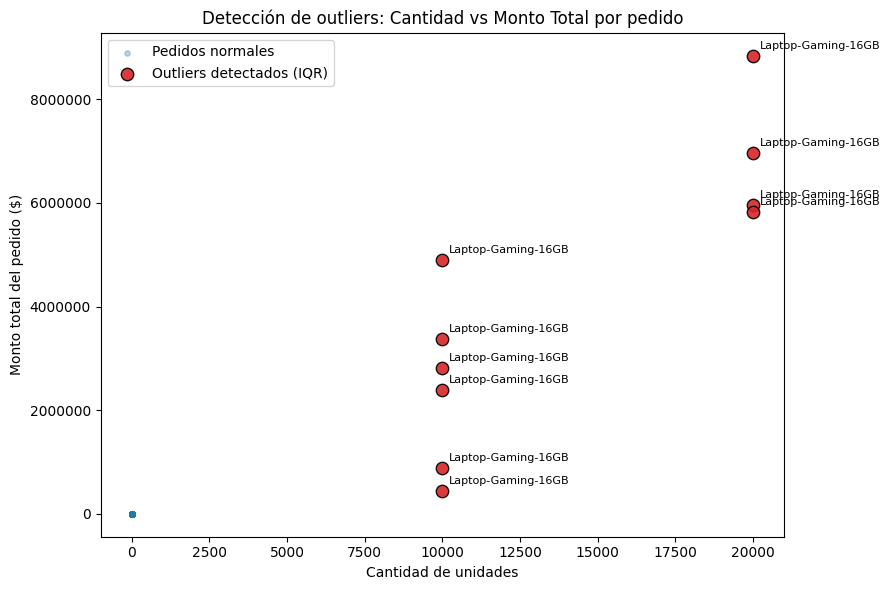

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,6))
normales = orders[~orders['outlier_monto']]
outliers = orders[orders['outlier_monto']]

ax.scatter(normales['cantidad'], normales['monto_total'], alpha=0.3, s=15,
           color='#1f77b4', label='Pedidos normales')
ax.scatter(outliers['cantidad'], outliers['monto_total'], alpha=0.9, s=80,
           color='#d62728', label='Outliers detectados (IQR)', edgecolor='black')

for _, row in outliers.iterrows():
    ax.annotate(row['nombre_producto'], (row['cantidad'], row['monto_total']),
                textcoords='offset points', xytext=(5,5), fontsize=8)

ax.set_xlabel('Cantidad de unidades')
ax.set_ylabel('Monto total del pedido ($)')
ax.set_title('Detección de outliers: Cantidad vs Monto Total por pedido')
ax.legend()
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

Al incluir 5 pedidos atípicos de Laptop-Gaming-16GB (10,000-20,000 unidades cada uno), este producto aparenta ser el más vendido con 144,206 unidades. Sin embargo, al excluir estos outliers, el resultado cambia completamente: no hay un producto dominante, sino tres productos con ventas similares (Vacuum-Pro-Black, Blender-XL-Red, Jacket-Winter-M, ~6,280-6,300 unidades c/u). Esto sugiere que los pedidos de Laptop-Gaming-16GB probablemente son errores de captura (o compras mayoristas atípicas) y no reflejan el comportamiento real de venta al consumidor.

In [ ]:
# Gasto de marketing por canal
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)
print('Gasto de marketing por canal:')
print(gasto_por_canal)

Gasto de marketing por canal:
canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64


### 🔍 Análisis adicional (extra, no solicitado en la guía)

Además de los KPIs pedidos, se incluye el siguiente análisis visual porque aporta
contexto útil para decisiones de marketing y expansión por país.

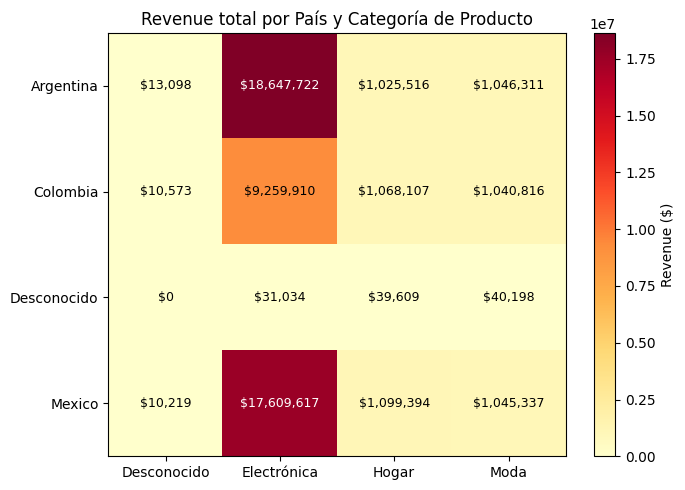

In [ ]:
# heatmap - Revenue por país y categoría

pivot = orders.pivot_table(index='pais', columns='categoria_producto',
                             values='monto_total', aggfunc='sum')
pivot = pivot.fillna(0)

fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'${val:,.0f}', ha='center', va='center', fontsize=9,
                color='white' if val > pivot.values.max()*0.5 else 'black')

ax.set_title('Revenue total por País y Categoría de Producto')
fig.colorbar(im, ax=ax, label='Revenue ($)')
plt.tight_layout()
plt.show()

**📊 Insight: Revenue por país y categoría**

Electrónica domina el revenue en los 3 países, muy por encima de Hogar y Moda (que se mantienen parejos entre sí, ~$1M cada uno por país). Sin embargo, Colombia genera prácticamente la mitad del revenue en Electrónica comparado con Argentina o México, mientras que en Hogar y Moda los tres países están muy parejos. Esto sugiere una oportunidad de crecimiento específica en Electrónica para el mercado colombiano.

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# Explorar todos los tipos de evento y su volumen
query_tipos_evento = '''
SELECT nombre_evento, COUNT(*) AS total_eventos, COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY total_eventos DESC;
'''
tipos_evento = pd.read_sql(query_tipos_evento, con=engine)
tipos_evento

,nombre_evento,total_eventos,usuarios_unicos
0,first_visit,29957,7796
1,add_to_cart,24157,7634
2,select_item,23887,7582
3,begin_checkout,17971,7208
4,add_payment_info,12018,6250
5,purchase,12010,6240


In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos
    FROM events
    GROUP BY nombre_evento
),
funnel_ordenado AS (
    SELECT
        nombre_evento,
        usuarios_unicos,
        ROW_NUMBER() OVER (ORDER BY usuarios_unicos DESC) AS paso
    FROM funnel
)
SELECT
    paso,
    nombre_evento,
    usuarios_unicos,
    ROUND(100.0 * usuarios_unicos / LAG(usuarios_unicos) OVER (ORDER BY paso), 2) AS tasa_conversion_paso_pct,
    ROUND(100.0 * usuarios_unicos / FIRST_VALUE(usuarios_unicos) OVER (ORDER BY paso), 2) AS pct_desde_inicio
FROM funnel_ordenado
ORDER BY paso;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,paso,nombre_evento,usuarios_unicos,tasa_conversion_paso_pct,pct_desde_inicio
0,1,first_visit,7796,NaN,100.00
1,2,add_to_cart,7634,97.92,97.92
2,3,select_item,7582,99.32,97.26
3,4,begin_checkout,7208,95.07,92.46
4,5,add_payment_info,6250,86.71,80.17
5,6,purchase,6240,99.84,80.04


**📉 Insight: Funnel de conversión**

La tasa de conversión final (first_visit → purchase) es del **80.04%**. El mayor cuello de botella está en el paso `begin_checkout → add_payment_info`, con una caída del 13.29% (-958 usuarios), muy por encima de cualquier otra etapa. En contraste, de `add_payment_info → purchase` la conversión es casi perfecta (99.84%), lo que indica que una vez que el usuario ingresa su información de pago, casi siempre completa la compra.

**Recomendación:** investigar la fricción específica en el formulario de método de pago (¿muy largo? ¿pocas opciones de pago? ¿errores técnicos?), ya que es la etapa con mayor oportunidad de mejora del funnel.

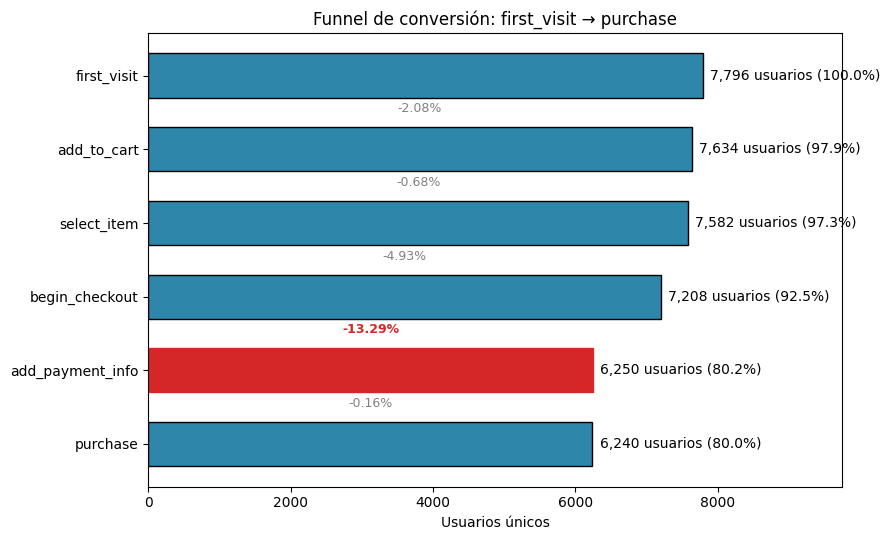

In [ ]:
# Usamos los datos que ya calculamos en 'conversion'
eventos = conversion['nombre_evento'].tolist()
usuarios = conversion['usuarios_unicos'].tolist()
pct_inicio = conversion['pct_desde_inicio'].tolist()

fig, ax = plt.subplots(figsize=(9,5.5))

colors = ['#2E86AB'] * len(eventos)
bars = ax.barh(range(len(eventos)), usuarios, color=colors, edgecolor='black', height=0.6)

# Resaltar en rojo el paso con la mayor caída (begin_checkout -> add_payment_info)
bars[4].set_color('#d62728')

ax.set_yticks(range(len(eventos)))
ax.set_yticklabels(eventos)
ax.invert_yaxis()  # el primer evento del funnel arriba

for i, (u, p) in enumerate(zip(usuarios, pct_inicio)):
    ax.text(u + 100, i, f'{u:,} usuarios ({p:.1f}%)', va='center', fontsize=10)

# Anotar la caída % entre cada paso consecutivo
for i in range(1, len(usuarios)):
    caida = round(100 * (usuarios[i-1] - usuarios[i]) / usuarios[i-1], 2)
    color = '#d62728' if i == 4 else 'gray'
    ax.annotate(f'-{caida}%', xy=(usuarios[i]/2, i-0.5), fontsize=9,
                color=color, ha='center', fontweight='bold' if i == 4 else 'normal')

ax.set_xlabel('Usuarios únicos')
ax.set_title('Funnel de conversión: first_visit → purchase')
ax.set_xlim(0, max(usuarios) * 1.25)
plt.tight_layout()
plt.show()

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE))::date AS mes_cohorte
    FROM users
),
actividad_semanal AS (
    SELECT
        id_usuario,
        MAX(CASE WHEN dias_despues_registro = 7  AND activo = 1 THEN 1 ELSE 0 END) AS retenido_w1,
        MAX(CASE WHEN dias_despues_registro = 14 AND activo = 1 THEN 1 ELSE 0 END) AS retenido_w2,
        MAX(CASE WHEN dias_despues_registro = 21 AND activo = 1 THEN 1 ELSE 0 END) AS retenido_w3
    FROM user_activity
    WHERE dias_despues_registro IN (7, 14, 21)
    GROUP BY id_usuario
),
combinado AS (
    SELECT
        c.id_usuario,
        c.mes_cohorte,
        COALESCE(a.retenido_w1, 0) AS retenido_w1,
        COALESCE(a.retenido_w2, 0) AS retenido_w2,
        COALESCE(a.retenido_w3, 0) AS retenido_w3
    FROM cohortes c
    LEFT JOIN actividad_semanal a ON c.id_usuario = a.id_usuario
)
SELECT
    mes_cohorte,
    COUNT(DISTINCT id_usuario) AS clientes_iniciales,
    SUM(retenido_w1) AS retenido_w1,
    SUM(retenido_w2) AS retenido_w2,
    SUM(retenido_w3) AS retenido_w3,
    ROUND(100.0 * SUM(retenido_w1) / COUNT(DISTINCT id_usuario), 2) AS semana_1,
    ROUND(100.0 * SUM(retenido_w2) / COUNT(DISTINCT id_usuario), 2) AS semana_2,
    ROUND(100.0 * SUM(retenido_w3) / COUNT(DISTINCT id_usuario), 2) AS semana_3
FROM combinado
GROUP BY mes_cohorte
ORDER BY mes_cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,mes_cohorte,clientes_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02-01,1444,611,609,635,42.31,42.17,43.98
2,2025-03-01,1636,677,705,690,41.38,43.09,42.18
3,2025-04-01,1606,680,697,663,42.34,43.40,41.28
4,2025-05-01,1687,695,676,706,41.20,40.07,41.85


**📊 Insight: Retención por cohortes**

La retención se mantiene estable entre 40% y 44% en las 5 cohortes mensuales analizadas (enero-mayo 2025), sin una caída progresiva típica entre semana 1, 2 y 3. Esto indica que el negocio no sufre de "abandono temprano" fuerte: los usuarios que permanecen activos
después de la primera semana tienden a mantenerse activos en las semanas siguientes, con un comportamiento muy consistente entre cohortes (ninguna semana o mes se desvía más de ~3 puntos porcentuales del resto).

**Conclusión:** no se identifica una cohorte problemática ni una tendencia de deterioro en el tiempo, lo cual es una señal saludable para el negocio.

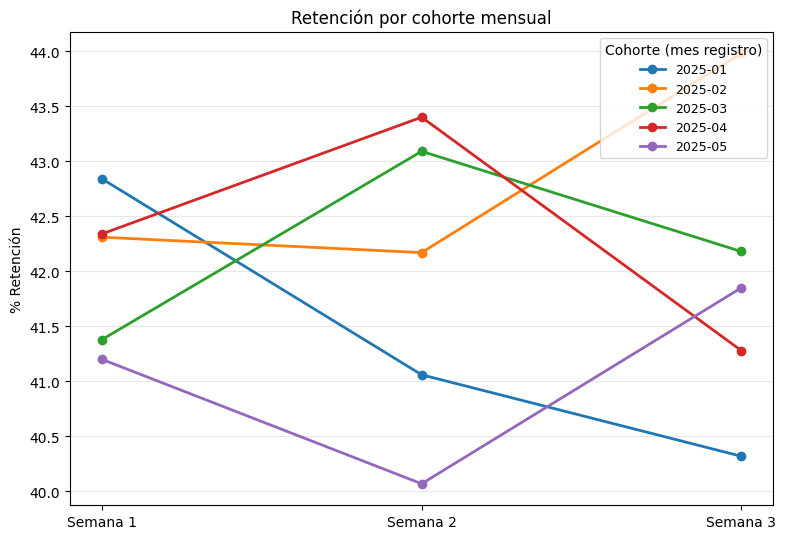

In [ ]:
fig, ax = plt.subplots(figsize=(8,5.5))

semanas = [1, 2, 3]
for _, row in cohorte_final.iterrows():
    valores = [row['semana_1'], row['semana_2'], row['semana_3']]
    ax.plot(semanas, valores, marker='o', label=str(row['mes_cohorte'])[:7], linewidth=2)

ax.set_xticks(semanas)
ax.set_xticklabels(['Semana 1', 'Semana 2', 'Semana 3'])
ax.set_ylabel('% Retención')
ax.set_title('Retención por cohorte mensual')
ax.legend(title='Cohorte (mes registro)', loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

In [ ]:
experiment = pd.read_csv('experiment_checkout_ui.csv')
experiment.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No hay diferencia en la tasa de conversión entre el grupo control y el grupo tratamiento (la nueva UI de checkout no tiene impacto).
   - **H₁ (Hipótesis alternativa):** Sí hay diferencia en la tasa de conversión entre el grupo control y el grupo tratamiento (la nueva UI de checkout sí tiene impacto).
   
**Test estadístico:** Test de proporciones de dos muestras (two-proportion z-test), porque la métrica `convirtio` es binaria (0/1) y estamos comparando la proporción de éxito entre dos grupos independientes.
**Nivel de significancia alpha:** 0.05

In [ ]:
# tu código aquí

from scipy import stats
import numpy as np

# Datos por grupo
control = experiment[experiment['variante'] == 'control']
tratamiento = experiment[experiment['variante'] == 'tratamiento']

n_control = len(control)
n_tratamiento = len(tratamiento)
conv_control = control['convirtio'].sum()
conv_tratamiento = tratamiento['convirtio'].sum()

tasa_control = conv_control / n_control
tasa_tratamiento = conv_tratamiento / n_tratamiento

print(f'Tasa de conversión control:     {tasa_control:.4f} ({conv_control}/{n_control})')
print(f'Tasa de conversión tratamiento: {tasa_tratamiento:.4f} ({conv_tratamiento}/{n_tratamiento})')
print(f'Diferencia: {(tasa_tratamiento - tasa_control)*100:.2f} puntos porcentuales')

# Test de proporciones de dos muestras
count = np.array([conv_tratamiento, conv_control])
nobs = np.array([n_tratamiento, n_control])

from statsmodels.stats.proportion import proportions_ztest
z_stat, p_value = proportions_ztest(count, nobs)

print(f'\nEstadístico z: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')

Tasa de conversión control:     0.1569 (779/4965)
Tasa de conversión tratamiento: 0.1629 (820/5035)
Diferencia: 0.60 puntos porcentuales

Estadístico z: 0.8133
p-value: 0.4161


In [ ]:
alpha = 0.05
if p_value < alpha:
    print(f'p-value ({p_value:.4f}) < alpha ({alpha}) → Se rechaza H₀')
    print('Conclusión: SÍ hay una diferencia estadísticamente significativa en la conversión.')
else:
    print(f'p-value ({p_value:.4f}) >= alpha ({alpha}) → No se rechaza H₀')
    print('Conclusión: NO hay evidencia suficiente de que la nueva UI cambie la conversión.')

p-value (0.4161) >= alpha (0.05) → No se rechaza H₀
Conclusión: NO hay evidencia suficiente de que la nueva UI cambie la conversión.


**🧪 Conclusión del test A/B**

Se comparó la tasa de conversión entre el grupo control (15.69%) y el grupo tratamiento con la nueva UI de checkout (16.29%), una diferencia de 0.60 puntos porcentuales.

Con un test de proporciones de dos muestras (z = 0.8133, p-value = 0.4161), **no se rechaza H₀**: no hay evidencia estadísticamente significativa de que la nueva UI mejore la conversión, dado un nivel de significancia de 0.05.

**Recomendación de negocio:** no se justifica implementar el cambio de UI basándose únicamente en este resultado. Se podría considerar:
- Aumentar el tamaño de muestra del experimento (correr el test más tiempo) para detectar diferencias más pequeñas con mayor poder estadístico, o
- Probar variaciones de diseño más distintivas, ya que un cambio muy sutil podría no ser suficiente para mover la aguja en el comportamiento del usuario.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

## 📊 Resumen Ejecutivo

**Rentabilidad:** El negocio es rentable, con un revenue de 51.99M, un profit bruto de 8.84M (17.01% de margen) y una inversión en marketing de 2.87M — que representa apenas ~5.5% del revenue, una proporción saludable.

**Geografía:** Argentina (20.7M) y México (19.8M) concentran la gran mayoría del revenue, mientras que Colombia genera bastante menos (11.4M) — casi la mitad. Esto se debe casi exclusivamente a la categoría Electrónica: es donde Colombia más se queda atrás frente a los otros dos países, mientras que en Hogar y Moda los tres mercados están parejos. Hay una oportunidad clara de crecimiento en Electrónica para Colombia.

**Categorías de producto:** Electrónica domina el revenue total (88% del total, 45.5M) frente a Hogar y Moda (3.2M cada una). El negocio depende fuertemente de una sola categoría — vale la pena evaluar si es una estrategia deliberada o un riesgo de concentración.

**Producto más vendido:** Sin contar los pedidos atípicos, no hay un producto dominante — Vacuum-Pro-Black, Blender-XL-Red, Jacket-Winter-M y Sneakers-Urban-42 venden volúmenes muy similares (~6,200-6,300 unidades cada uno).

**Marketing:** La inversión está bien distribuida entre los 3 canales (organic, paid_search, social), sin ninguno dominando desproporcionadamente — sugiere una estrategia de adquisición diversificada.

**Comportamiento de compra:** Ticket promedio de 2,079 por pedido, con 7 productos por orden en promedio.

**Riesgo operativo:** La tabla de detalle muestra pedidos individuales con pérdida (profit negativo) mezclados con pedidos rentables — vale la pena investigar si hay un patrón (¿ciertos productos, ciertos descuentos?) detrás de esas pérdidas puntuales.

**Funnel y retención (Python/SQL):** La conversión general del funnel es del 80.04%, con el mayor cuello de botella entre `begin_checkout` y `add_payment_info` (-13.29%). La retención por cohortes se mantiene estable entre 40-44% en las 5 cohortes mensuales analizadas, sin señales de deterioro.

**Test A/B (checkout UI):** No se encontró evidencia estadísticamente significativa (p-value = 0.4161) de que la nueva UI de checkout mejore la conversión frente al diseño actual.

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [ ]:
# (Pega aquí tu link)
# link de power bi o tableau
# link de one drive / google drive

https://public.tableau.com/views/Sprint12_17846898949130/OverviewEjecutivo?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link